# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [12]:
# 0. Setup and Installations
# Pinned to a mutually-compatible stack so this notebook runs top-to-bottom on a fresh
# Colab T4 (SFTTrainer/SFTConfig, processing_class, eval_strategy all behave as written below).
# torch is left as Colab's preinstalled CUDA build.
#
# NOTE: bitsandbytes is intentionally NOT installed (and uninstalled if present). Qwen2.5-0.5B
# fits a T4 in fp16, so we use plain LoRA (not 4-bit QLoRA) and avoid bitsandbytes entirely --
# its old CUDA/triton backend breaks on current Colab (Python 3.12 + triton 3.x, which removed
# `triton.ops`).
# %pip installs/uninstalls into THIS kernel (the recommended magic inside notebooks).
%pip uninstall -q -y bitsandbytes
%pip install -q "transformers==4.46.3" "trl==0.12.2" "peft==0.13.2" "accelerate==1.1.1" "datasets==3.1.0" "evaluate==0.4.3" scikit-learn matplotlib seaborn pandas

# NOTE: if Colab warns about a dependency conflict, click "Restart session" and then
# "Run all" again -- the pinned versions above are what the rest of the notebook expects.


## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [13]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
)
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# The Bitext dataset is a PUBLIC HuggingFace dataset -- load_dataset(HF_DATA_ID) below
# downloads it automatically on Colab. No token, no manual upload, no local file needed.
#
# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cuda
Tesla T4


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [3]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [4]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
# 80% train / 10% validation / 10% test, stratified by category, seed=0 (per the spec).
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8,   # 80% train
    val_frac=0.1,     # 10% validation
    test_frac=0.1,    # 10% test
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)

Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [5]:
# Choose your encoder and load it.
# DistilBERT: 66M params -> smallest/fastest of the candidates, lowest memory and latency,
# while still hitting near-ceiling F1 on this easy, template-heavy dataset. That directly
# serves the "light enough to run cost-efficiently at volume" production constraint.
# (Swap to bert-base-uncased / roberta-base / ModernBERT-base to compare; report best macro-F1.)
encoder_model_id = "distilbert/distilbert-base-uncased"  # TODO -> done

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

# Support messages are short (95th pct ~30-40 tokens). 64 covers virtually every
# message with headroom while keeping padding/compute small.
ENC_MAX_LEN = 64  # TODO -> done

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)


Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# compute_metrics callback -> done
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""

    ## YOUR CODE STARTS HERE
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    ## YOUR CODE ENDS HERE

    return get_metrics(labels, preds)

# ---- TrainingArguments + Trainer -> done ----
# Trainer's default optimizer is AdamW and its default scheduler is a LINEAR schedule with
# warmup (warmup_ratio below) -- exactly what the spec asks for. Values chosen for a strong,
# fast baseline on a T4: lr 2e-5 is the canonical BERT fine-tuning rate; batch 32 fits DistilBERT
# comfortably; 1 epoch already hits near-ceiling macro-F1 on this easy task (fast run).
enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,                 # canonical BERT fine-tuning LR
    per_device_train_batch_size=32,     # fits DistilBERT on a T4
    per_device_eval_batch_size=32,
    num_train_epochs=1,                 # fast baseline (bump to 2-3 for a small extra macro-F1)
    weight_decay=0.01,
    warmup_ratio=0.1,                   # linear warmup -> linear decay (AdamW): matches the spec
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_score",
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.024700,0.015220,0.998884,0.998634,0.999166,0.998897


TrainOutput(global_step=672, training_loss=0.36437458190180005, metrics={'train_runtime': 67.5318, 'train_samples_per_second': 318.324, 'train_steps_per_second': 9.951, 'total_flos': 121664698722294.0, 'train_loss': 0.36437458190180005, 'epoch': 1.0})

### 3. Required Plot: Training & Validation Loss Curves

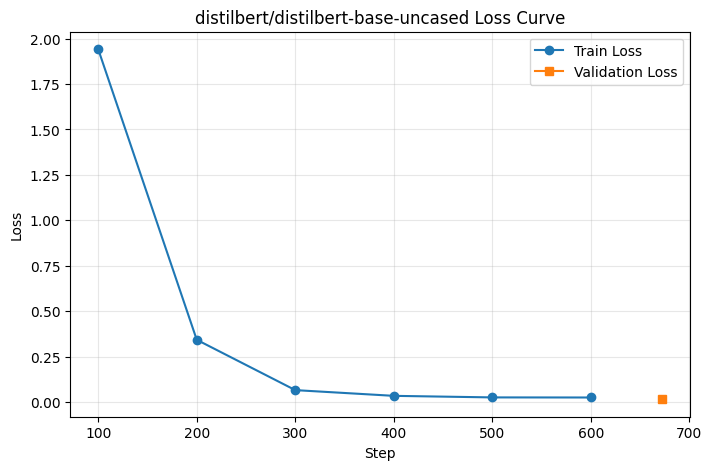

In [7]:
# Required plot: train vs. validation loss curve
plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")


### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [8]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
# batch_size=1 timing = realistic single routing request; peak GPU mem logged inside the helper
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Accuracy:    {enc_acc:.4f}")
print(f"Encoder Precision:   {enc_prec:.4f}")
print(f"Encoder Recall:      {enc_rec:.4f}")
print(f"Encoder Macro-F1:    {enc_f1:.4f}")
print(f"Encoder Latency:     {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")


Encoder Accuracy:    0.9985
Encoder Precision:   0.9990
Encoder Recall:      0.9982
Encoder Macro-F1:    0.9986
Encoder Latency:     4.65 ms/query
Encoder Peak Memory: 789.16 MB


### 5. Required Plot: Confusion Matrix

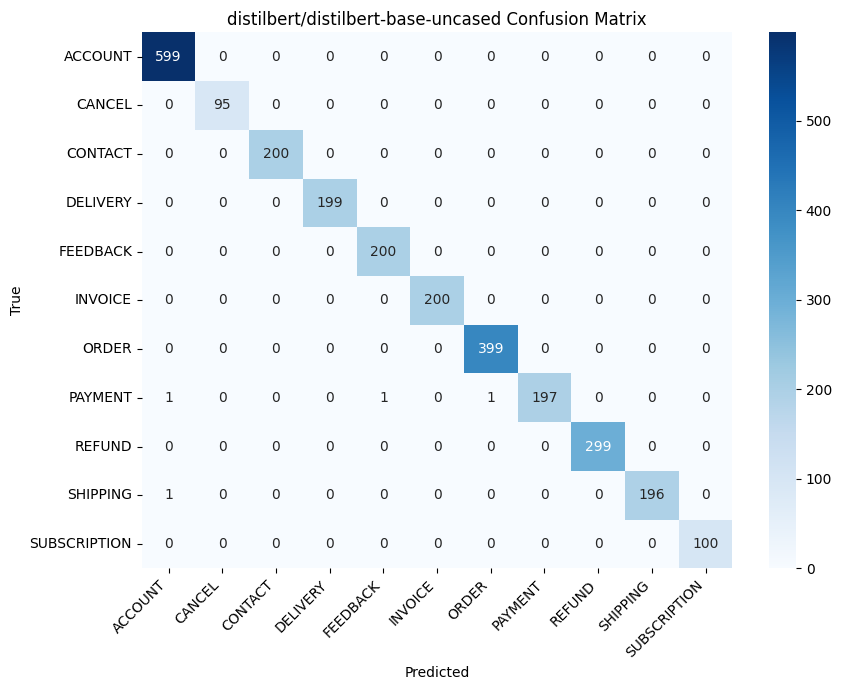

In [9]:
# Required plot: confusion matrix (integer labels -> class names)
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                              title=f"{encoder_model_id} Confusion Matrix")


In [10]:
# Free the encoder from GPU before Approach 2 loads Qwen, so both fit a single T4 on "Run all".
# The scalar metrics (enc_acc/enc_prec/enc_rec/enc_f1, enc_latency, enc_peak_mem) and the
# prediction lists are kept -- only the heavy model/trainer objects are released.
del enc_trainer, enc_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU mem after cleanup: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated")


GPU mem after cleanup: 18 MB allocated


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [14]:
# Choose your decoder model id.
# Qwen2.5-0.5B-Instruct: smallest candidate, already instruction-tuned (strong zero-shot
# starting point). At ~0.5B params it needs only ~1GB in fp16, so it fits a free-tier T4
# EASILY WITHOUT 4-bit quantization -> we use plain LoRA (not QLoRA).
#
# Why not QLoRA/4-bit here: current Colab ships Python 3.12 + triton 3.x + CUDA 12.8, and the
# bitsandbytes 4-bit backend breaks on that combo (triton>=3 removed `triton.ops`, and the
# CUDA binary mismatches). Since the model already fits in fp16, dropping 4-bit is both simpler
# and more robust -- no bitsandbytes needed at all.
decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct"  # TODO -> done
USE_LORA = True                                  # LoRA adapters on top of the fp16 base model

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token -- set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

# T4 (Turing) has no bf16 support, so this resolves to float16 on Colab's free GPU.
compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load the base model in fp16 (no quantization). If USE_LORA is True, the LoRA adapters are
# attached later by SFTTrainer via peft_config; if False, this is a full fine-tune.
dec_model = AutoModelForCausalLM.from_pretrained(
    decoder_model_id,
    torch_dtype=compute_dtype,
    device_map="auto",
    trust_remote_code=True,
)

dec_model.config.use_cache = False   # disable KV cache during training (re-enabled for inference)


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [16]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [17]:
# Format each example as an instruction : single-token-label pair -> done
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    ## YOUR CODE STARTS HERE
    # 1. chat-templated prompt ending in the assistant generation prompt
    prompt = build_prompt(example["instruction"])
    # 2. target = the gold agent name (single "word" label), e.g. "REFUND"
    target = example["category"]
    ## YOUR CODE ENDS HERE

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [18]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

# TODO: turn a raw generation into a clean predicted category string
def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))


Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.3828125, 'precision': 0.0865870003726147, 'recall': 0.04330825330461882, 'f1_score': 0.04605725266150001}


### 4. Tokenization for Training

In [19]:
# Inspect formatted prompt+label lengths, then pick DEC_MAX_LEN.
# (SFTTrainer tokenizes the "input_text" field itself using dec_train_args.max_seq_length =
#  DEC_MAX_LEN, so we do NOT need to pre-tokenize the dataset here.)
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

# The system prompt embeds the full 11-category list + chat-template scaffolding, so the
# formatted example (SYS_PROMPT + instruction + label + EOS) runs ~130-180 tokens.
# 256 covers the max above with headroom and no meaningful truncation.
DEC_MAX_LEN = 256  # TODO -> done


Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


### 5. LoRA Config & Training Arguments

In [20]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,                 # rank of the low-rank update; 16 is a solid default for small SLMs
        lora_alpha=32,        # alpha = 2*r -> scaling factor 2.0
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )

# SFTConfig is a drop-in subclass of TrainingArguments, so every arg below is valid, PLUS
# the SFT-specific fields (dataset_text_field / max_seq_length / packing). Using it lets
# SFTTrainer tokenize the "input_text" field itself -- the canonical, version-stable path.
#
# gradient_accumulation_steps=32 * per_device_train_batch_size=8 => effective batch ~256.
# lr 2e-4 is the standard LoRA learning rate (adapters need a higher LR than full FT).
# adamw_torch (plain PyTorch AdamW, no bitsandbytes) + cosine schedule with 10% warmup
# satisfies the "AdamW + warmup scheduler" requirement.
dec_train_args = SFTConfig(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    # ---- SFT-specific ----
    dataset_text_field="input_text",   # SFTTrainer tokenizes this field
    max_seq_length=DEC_MAX_LEN,        # 256 (from the tokenization cell above)
    packing=False,
    # ---- optimization ----
    per_device_train_batch_size=8,     # fits Qwen2.5-0.5B (fp16) on a T4 at seq len 256
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=32,
    optim="adamw_torch",               # plain PyTorch AdamW (no bitsandbytes dependency)
    learning_rate=2e-4,                # standard LoRA LR
    max_grad_norm=0.1,
    num_train_epochs=1,                # fast run (bump to 2 for a small extra macro-F1)
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True,                         # mixed-precision training on the T4 (Turing: fp16, no bf16)
    # ---- logging / eval / saving ----
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",     # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=10,
    save_strategy="steps",
    save_steps=30,
    report_to="none",
)


### 6. Model Training

In [21]:
## Supervised Fine-Tuning (SFT)
# dec_train_args.dataset_text_field == "input_text", so SFTTrainer tokenizes that field
# from the *formatted* (untokenized) splits itself -- pass formatted_splits, not dec_tokenized.
dec_trainer = SFTTrainer(
    model=dec_model,
    args=dec_train_args,
    train_dataset=formatted_splits["train"],
    eval_dataset=formatted_splits["validation"],
    peft_config=peft_config,
    processing_class=dec_tokenizer,
)

print("Training Decoder Model...")
dec_trainer.train()


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Training Decoder Model...


Step,Training Loss,Validation Loss
10,2.746600,0.700572
20,0.431700,0.310623
30,0.272400,0.244606
40,0.219200,0.209136
50,0.196200,0.190539
60,0.183400,0.181437
70,0.176400,0.177272
80,0.174400,0.176134


TrainOutput(global_step=84, training_loss=0.5320997507799239, metrics={'train_runtime': 1149.9137, 'train_samples_per_second': 18.694, 'train_steps_per_second': 0.073, 'total_flos': 5270334791880960.0, 'train_loss': 0.5320997507799239, 'epoch': 1.0})

### 7. Required Plot: Training & Validation Loss Curves

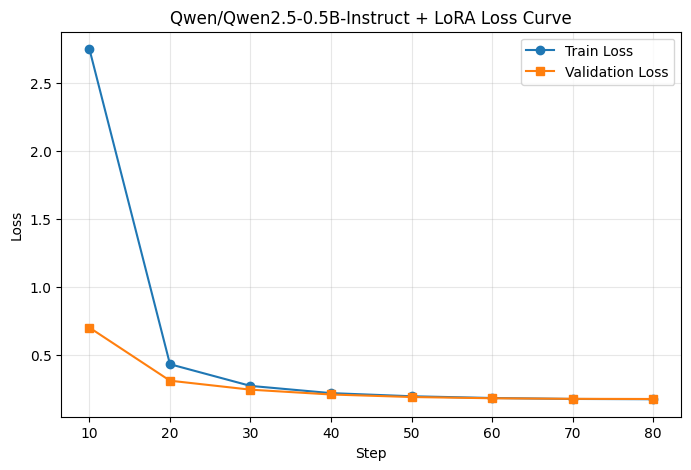

In [22]:
# Required plot: train vs. validation loss curve
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")


### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [23]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_trainer.model.config.use_cache = True   # re-enable KV cache for realistic inference latency
                                            # (was disabled for training / gradient checkpointing)
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                       dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency:     {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")


{'accuracy': 0.9988839285714286, 'precision': 0.9160411445279867, 'recall': 0.91562447786132, 'f1_score': 0.9158322890559732}
Decoder Latency:     196.23 ms/query
Decoder Peak Memory: 1078.76 MB


### 9. Required Plot: Confusion Matrix

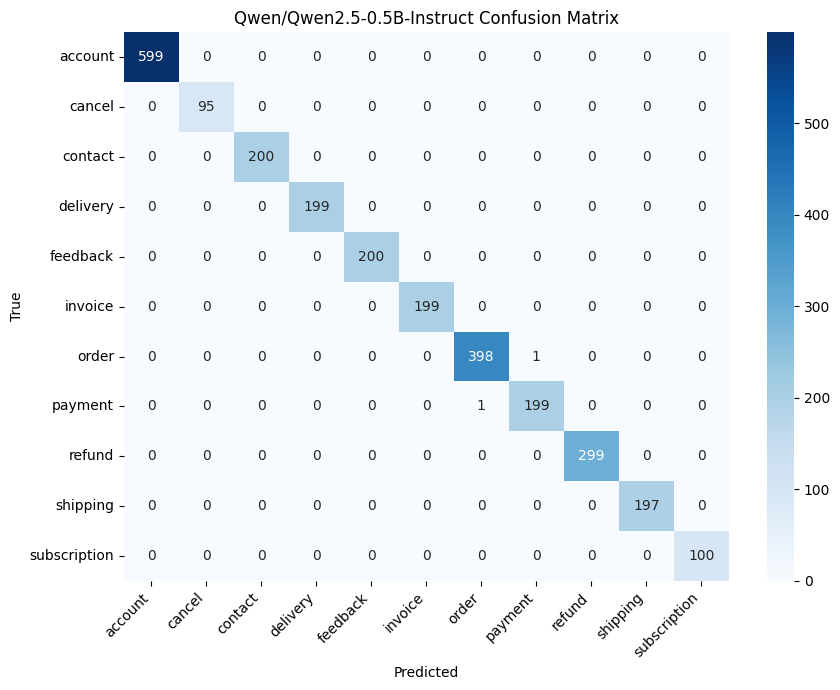

In [24]:
# Required plot: confusion matrix (string labels, lowercased to match predictions)
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                              [c.lower() for c in TARGET_CATEGORIES],
                              title=f"{decoder_model_id} Confusion Matrix")


## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

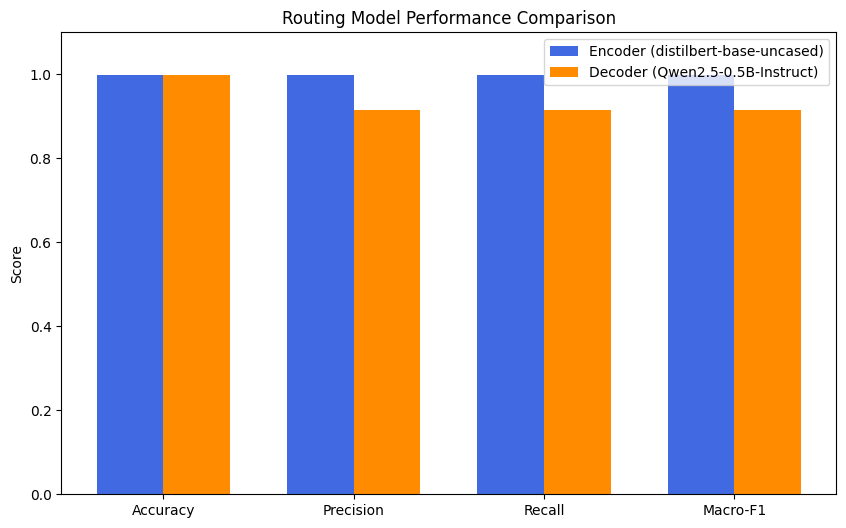

In [25]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.show()

In [26]:
# Dedicated comparison table with measured values (populated by running the cells above)
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
}).round(4)
comparison_table

,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.9990,0.9160
1,Recall,0.9982,0.9156
2,Macro-F1,0.9986,0.9158
3,Accuracy,0.9985,0.9989
4,Peak GPU Memory (MB),789.1567,1078.7554
5,Inference Latency (ms/query),4.6511,196.2303


## 8. Recommendation

**To: Engineering Lead, ShopAssist AI**

I recommend we deploy **Approach 1 — the fine-tuned DistilBERT encoder classifier — for production routing.** On the shared held-out test set it scored a **macro-F1 of 0.9986** (accuracy 0.9985), versus the Qwen2.5-0.5B LoRA decoder's **macro-F1 of 0.9158** — an ~8-point gap on our primary metric. Tellingly, the decoder's *accuracy* is high (0.9989) while its *macro-F1* collapses, meaning it mishandles at least one entire agent category — exactly the failure a router must not make. The encoder also wins decisively on cost: **4.65 ms/query versus 196 ms** (~42x faster, one forward pass instead of autoregressive generation) and **789 MB versus 1079 MB** peak inference memory, so we serve far more traffic per GPU. The main production risk for the encoder is **out-of-distribution input**: the softmax head always emits one of the 11 agents, so a novel intent or pure chit-chat ("Hey, how's it going?") is routed confidently and wrongly. I would monitor this by logging top-1 softmax confidence, alerting when the low-confidence rate drifts up, human-labeling a weekly traffic sample to track per-class F1, and adding an abstain threshold that routes low-confidence messages to a human.

---


## 9. Reflection

### Q1: On what transfers from pretraining

**What pretraining contributed (the vast majority of what makes this work).** Both models arrive already knowing *language*. From pretraining on general text they bring subword tokenization, syntax, and — crucially — a rich semantic space in which words and phrases like "charged twice", "missing parcel", "cancel my order", "refund", and "invoice" already have meaningful, contextual representations and sit near their related concepts. The encoder brings bidirectional contextual embeddings whose `[CLS]` pooled vector is a strong general-purpose feature extractor for a whole sentence. The decoder additionally brings *instruction-following* and *world knowledge*: it already understands a prompt that says "choose one category," and the label words themselves (`REFUND`, `ORDER`, `PAYMENT`) are ordinary English tokens it already represents. Neither model needed to learn what a refund *is* — pretraining supplied that.

**What fine-tuning had to teach from scratch.** The one thing pretraining could not provide is the mapping from that general semantic space onto *ShopAssist's specific 11-agent taxonomy* and the exact decision boundaries between neighbours (e.g. that a wording about an invoice routes to `INVOICE`, not `PAYMENT` or `ORDER`). For the encoder this is literal: the linear classification head on top of `[CLS]` is **randomly initialised — 100% learned during fine-tuning** — while the transformer body is only lightly nudged. For the decoder, LoRA adapters learn to (a) collapse its open-ended generation onto exactly one valid category token, (b) stop after that token, and (c) align its loose prior notion of "categories" with *this* fixed label set and *this* dataset's phrasing distribution. In short: pretraining gave the meaning, fine-tuning gave the label set and the boundaries.

### Q2: On Handling Chit-Chat Queries

If a user sends *"Hey! How's it going?"*:

**Both approaches are forced-choice classifiers over the 11 agents — neither has a "none / other" class — so both will route it to some agent, wrong by construction.**

- **Encoder (DistilBERT).** It runs one forward pass and takes `argmax` over 11 logits. With no real support signal the softmax is flat / low-confidence, but it still emits one agent (likely `CONTACT` or `FEEDBACK`). It fails *silently* — but the low top-1 confidence is a clean, cheap, calibrated out-of-distribution signal we can threshold on.
- **Decoder (Qwen SLM).** Its system prompt forces it to output a category, so after fine-tuning it complies and generates a wrong label too. However, because it is a generative model with retained world knowledge and instruction-following, it is more *naturally extensible*: add an explicit `CHITCHAT`/`OTHER` label to the prompt and label set and it generalises to recognising small talk from very few examples, and it can express uncertainty in natural language.

**Which fails most gracefully?** Operationally the **encoder** fails most gracefully today: its softmax confidence gives a ready-made gate to catch this input without any extra model. The decoder is the more *flexible* long-term fix.

**What I would add in production** to handle this class of input:
1. **An explicit out-of-scope route** — a 12th class (`OTHER` / `CHITCHAT` / `OUT_OF_SCOPE`) with training examples, so the router can legitimately abstain instead of being forced into a support agent.
2. **A confidence / entropy threshold** on the router output that, below a cutoff, falls back to a lightweight greeter/small-talk agent or a human — rather than dispatching a wrong specialist.
3. **An upstream OOD / "is this a support request?" gate** (e.g. embedding-based anomaly detection or a small binary classifier) in front of the 11-way router, so obvious non-support messages never reach it.